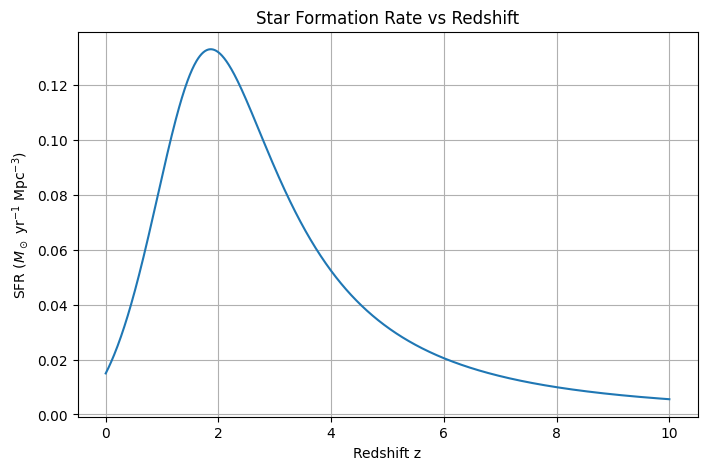

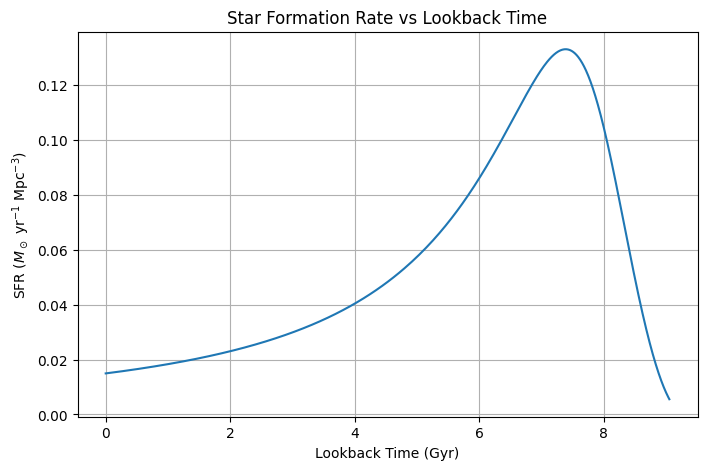

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hubble constant: 70 km/s/Mpc
# Convert to s^-1

MPC_IN_KM = 3.086e19
H0 = 70 / MPC_IN_KM   # s^-1

SECONDS_PER_GYR = 365.25 * 24 * 3600 * 1e9


z = np.linspace(0, 10, 1000)

# --------------------------------------------------
# Star Formation Rate function
# SFR in units of Msun yr^-1 Mpc^-3
# --------------------------------------------------

sfr = 0.015 * (1 + z)**2.7 / (1 + ((1 + z) / 2.9)**5.6)

# --------------------------------------------------
# Lookback time function
#
# t(z) = (2 / 3H0) * (1 - 1/(1+z)^(3/2))
#
# Result initially in seconds
# --------------------------------------------------

t_seconds = (2 / (3 * H0)) * (1 - 1 / (1 + z)**1.5)

t_gyr = t_seconds / SECONDS_PER_GYR

# --------------------------------------------------
# Plot 1: SFR vs Redshift
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(z, sfr)

plt.xlabel("Redshift z")
plt.ylabel(r"SFR ($M_\odot\ \mathrm{yr}^{-1}\ \mathrm{Mpc}^{-3}$)")
plt.title("Star Formation Rate vs Redshift")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Plot 2: SFR vs Lookback Time
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(t_gyr, sfr)

plt.xlabel("Lookback Time (Gyr)")
plt.ylabel(r"SFR ($M_\odot\ \mathrm{yr}^{-1}\ \mathrm{Mpc}^{-3}$)")
plt.title("Star Formation Rate vs Lookback Time")

plt.grid(True)

plt.show()

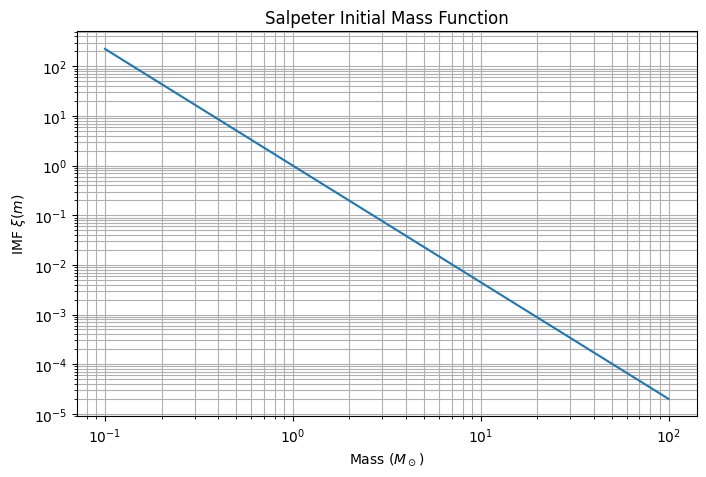

In [3]:
from scipy.integrate import quad

# --------------------------------------------------
# IMF function
# xi(m) proportional to m^(-2.35)
# --------------------------------------------------

def imf(m):
    return m**(-2.35)

# --------------------------------------------------
# Plot IMF
# --------------------------------------------------

m = np.logspace(-1, 2, 1000)   # 0.1 to 100 Msun

xi = imf(m)

plt.figure(figsize=(8,5))

plt.loglog(m, xi)

plt.xlabel(r"Mass ($M_\odot$)")
plt.ylabel(r"IMF $\xi(m)$")
plt.title("Salpeter Initial Mass Function")

plt.grid(True, which="both")

plt.show()

# --------------------------------------------------
# Number of stars between 0.9 and 1.0 Msun
# --------------------------------------------------

N_low, err1 = quad(imf, 0.9, 1.0)

# --------------------------------------------------
# Number of stars between 90 and 100 Msun
# --------------------------------------------------

N_high, err2 = quad(imf, 90, 100)

ratio = N_low / N_high

# print("Ratio of stars:")
# print("0.9-1.0 Msun / 90-100 Msun =", ratio)

# --------------------------------------------------
# Fraction of stars above 8 Msun
# --------------------------------------------------

N_SN, err3 = quad(imf, 8, 100)

N_total, err4 = quad(imf, 0.1, 100)

fraction_SN = N_SN / N_total

# print()
# print("Fraction of stars above 8 Msun:")
# print(fraction_SN)

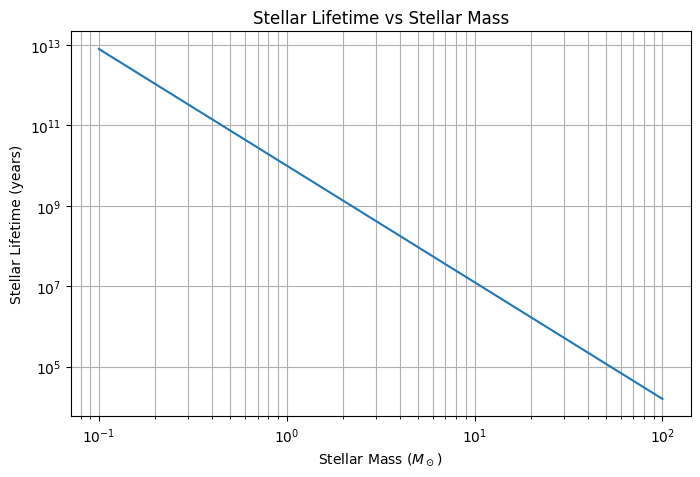

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Stellar mass range
# --------------------------------------------------

M = np.logspace(-1, 2, 1000)   # 0.1 to 100 Msun

# --------------------------------------------------
# Stellar lifetime
#
# Luminosity relation:
#
# L ∝ M^3.9
#
# Stellar lifetime:
#
# tau ∝ M / L
#
# Therefore:
#
# tau ∝ M^(-2.9)
#
# Assume solar lifetime:
#
# tau_sun = 1e10 yr
# --------------------------------------------------

tau = 1e10 * M**(-2.9)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.loglog(M, tau)

plt.xlabel(r"Stellar Mass ($M_\odot$)")
plt.ylabel("Stellar Lifetime (years)")

plt.title("Stellar Lifetime vs Stellar Mass")

plt.grid(True, which="both")

plt.show()

In [ ]:
import numpy as np
from scipy.integrate import quad

# --------------------------------------------------
# Salpeter IMF
#
# xi(m) proportional to m^(-2.35)
# --------------------------------------------------

def imf(m):
    return m**(-2.35)

# --------------------------------------------------
# Stellar lifetime function
#
# tau(M) = 1e10 * M^(-2.9) years
# --------------------------------------------------

def lifetime(m):
    return 1e10 * m**(-2.9)

# --------------------------------------------------
# Solve for cutoff mass
#
# tau(M_cut) = age
#
# Therefore:
#
# M_cut = (1e10 / age)^(1/2.9)
# --------------------------------------------------

def cutoff_mass(age_years):
    return (1e10 / age_years)**(1/2.9)

# --------------------------------------------------
# Compute burned-out fraction
#
# Stars with:
#
# M > M_cut
#
# have already died.
# --------------------------------------------------

def burned_fraction(age_years):

    # cutoff mass
    M_cut = cutoff_mass(age_years)

    # keep within IMF mass range
    if M_cut > 100:
        return M_cut, 0

    # stars already dead
    N_dead, err1 = quad(imf, M_cut, 100)

    # total stars originally formed
    N_total, err2 = quad(imf, 0.1, 100)

    fraction_dead = N_dead / N_total

    return M_cut, fraction_dead

# --------------------------------------------------
# Stars formed 8 billion years ago
# --------------------------------------------------

age_8Gyr = 8e9

Mcut_8, frac_8 = burned_fraction(age_8Gyr)

# print("Stars formed 8 billion years ago")
# print("--------------------------------")
# print("Cutoff mass =", Mcut_8, "Msun")
# print("Fraction burned out =", frac_8)

# print()

# --------------------------------------------------
# Stars formed 2 billion years ago
# --------------------------------------------------

age_2Gyr = 2e9

Mcut_2, frac_2 = burned_fraction(age_2Gyr)

# print("Stars formed 2 billion years ago")
# print("--------------------------------")
# print("Cutoff mass =", Mcut_2, "Msun")
# print("Fraction burned out =", frac_2)

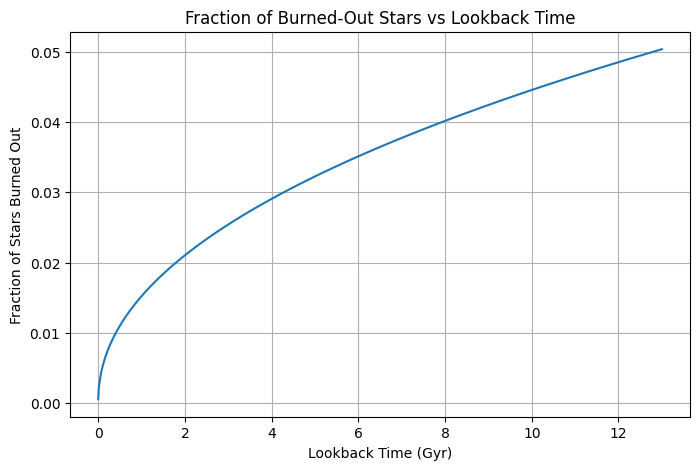

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --------------------------------------------------
# Salpeter IMF
# --------------------------------------------------

def imf(m):
    return m**(-2.35)

# --------------------------------------------------
# Stellar lifetime
#
# tau(M) = 1e10 * M^(-2.9) years
# --------------------------------------------------

def lifetime(m):
    return 1e10 * m**(-2.9)

# --------------------------------------------------
# Cutoff mass
#
# tau(M_cut) = age
#
# M_cut = (1e10 / age)^(1/2.9)
# --------------------------------------------------

def cutoff_mass(age_years):
    return (1e10 / age_years)**(1/2.9)

# --------------------------------------------------
# Burned-out fraction
# --------------------------------------------------

def burned_fraction(age_years):

    M_cut = cutoff_mass(age_years)

    # Limit to IMF range
    if M_cut > 100:
        return 0

    # Stars already dead
    N_dead, err1 = quad(imf, M_cut, 100)

    # Total stars formed
    N_total, err2 = quad(imf, 0.1, 100)

    return N_dead / N_total

# --------------------------------------------------
# Lookback time array
#
# 1 million years to 13 billion years
# --------------------------------------------------

t = np.linspace(1e6, 13e9, 1000)

# --------------------------------------------------
# Compute burned fraction for each age
# --------------------------------------------------

f_dead = np.array([burned_fraction(age) for age in t])

# --------------------------------------------------
# Convert time to Gyr
# --------------------------------------------------

t_gyr = t / 1e9

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(t_gyr, f_dead)

plt.xlabel("Lookback Time (Gyr)")
plt.ylabel("Fraction of Stars Burned Out")

plt.title("Fraction of Burned-Out Stars vs Lookback Time")

plt.grid(True)

plt.show()

In [ ]:
# --------------------------------------------------
# Fraction of stars still alive today
#
# f_alive = 1 - f_dead
# --------------------------------------------------

f_alive = 1 - f_dead

# --------------------------------------------------
# IMPORTANT:
#
# t_gyr from earlier corresponds to the same z grid
# used to compute sfr.
#
# We should sort by increasing time before integrating.
# --------------------------------------------------

idx = np.argsort(t_gyr)

t_sorted = t_gyr[idx]
sfr_sorted = sfr[idx]

# --------------------------------------------------
# Interpolate survival fraction onto same time grid
# --------------------------------------------------

f_alive_interp = np.interp(
    t_sorted,
    t / 1e9,     # original f_dead time grid in Gyr
    f_alive
)

# --------------------------------------------------
# Compute integrals
# --------------------------------------------------

# Total stars ever formed
N_formed = np.trapz(sfr_sorted, t_sorted)

# Stars still alive today
N_alive = np.trapz(
    sfr_sorted * f_alive_interp,
    t_sorted
)

# --------------------------------------------------
# Final fraction
# --------------------------------------------------

fraction_alive_today = N_alive / N_formed

# print("Fraction of stars ever formed")
# print("that are still alive today:")

# print(fraction_alive_today)

In [ ]:
# --------------------------------------------------
# Part (g)
#
# Estimate the fraction of all stars that will
# ever form that have already formed.
#
# We use:
#
# fraction =
#
# (stars formed in the past)
# --------------------------------
# (stars formed past + future)
#
# The SFR is integrated over cosmic time.
#
# IMPORTANT:
# Future cosmic evolution corresponds to:
#
# -1 < z < 0
#
# because:
#
# a = 1 / (1 + z)
#
# and future expansion means z -> -1^+
# --------------------------------------------------

import numpy as np

# --------------------------------------------------
# Redshift grid
#
# z = 10      -> early universe
# z = 0       -> today
# z -> -1^+   -> infinite future
# --------------------------------------------------

z = np.linspace(-0.999, 10, 200000)

# --------------------------------------------------
# Star Formation Rate
# --------------------------------------------------

sfr = 0.015 * (1 + z)**2.7 / (
    1 + ((1 + z) / 2.9)**5.6
)

# --------------------------------------------------
# Lookback time
#
# Positive  -> past
# Zero      -> today
# Negative  -> future
# --------------------------------------------------

t_seconds = (2 / (3 * H0)) * (
    1 - 1 / (1 + z)**1.5
)

t_gyr = t_seconds / SECONDS_PER_GYR

# --------------------------------------------------
# Sort arrays by increasing time
# --------------------------------------------------

idx = np.argsort(t_gyr)

t_sorted = t_gyr[idx]
sfr_sorted = sfr[idx]

# --------------------------------------------------
# Total stars that will ever form
#
# Integrate over:
#
# future + past
#
# i.e. all cosmic time represented here
# --------------------------------------------------

N_total = np.trapz(sfr_sorted, t_sorted)

# --------------------------------------------------
# Stars already formed
#
# Past universe only:
#
# t >= 0
# --------------------------------------------------

mask_past = t_sorted >= 0

N_past = np.trapz(
    sfr_sorted[mask_past],
    t_sorted[mask_past]
)

# --------------------------------------------------
# Final fraction
# --------------------------------------------------

fraction = N_past / N_total

# print("Fraction of all stars that will ever form")
# print("that have already formed:")

# print(fraction)

In [ ]:
# --------------------------------------------------
# Passive fading of the Milky Way
#
# Assume:
#
# - Star formation stops today
# - Stellar luminosity:
#
#     L(M) ∝ M^3.9
#
# - Salpeter IMF:
#
#     xi(M) ∝ M^-2.35
#
# - Stellar lifetime:
#
#     tau(M) = 1e10 * M^-2.9 yr
#
# We compute:
#
#     L(t)/L(0)
#
# and determine when the Milky Way becomes
# fainter than V = 30 mag from Virgo.
# --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --------------------------------------------------
# IMF
# --------------------------------------------------

def imf(m):
    return m**(-2.35)

# --------------------------------------------------
# Stellar luminosity
# --------------------------------------------------

def luminosity(m):
    return m**(3.9)

# --------------------------------------------------
# Stellar lifetime
# --------------------------------------------------

def lifetime(m):
    return 1e10 * m**(-2.9)

# --------------------------------------------------
# Cutoff mass
#
# Stars more massive than this are dead
# --------------------------------------------------

def cutoff_mass(age_years):
    return (1e10 / age_years)**(1/2.9)

# --------------------------------------------------
# Total galaxy luminosity at time t
# --------------------------------------------------

def galaxy_luminosity(age_years):

    M_cut = cutoff_mass(age_years)

    # no stars remaining
    if M_cut < 0.1:
        return 0

    # cap at IMF upper limit
    M_cut = min(M_cut, 100)

    # integrate surviving stellar luminosity
    L_total, err = quad(
        lambda m: imf(m) * luminosity(m),
        0.1,
        M_cut
    )

    return L_total

# --------------------------------------------------
# Present-day luminosity
# --------------------------------------------------

L0 = galaxy_luminosity(1e6)

# --------------------------------------------------
# Time array
#
# 1 million years to 10 trillion years
# --------------------------------------------------

t = np.logspace(6, 13, 1000)

# --------------------------------------------------
# Luminosity evolution
# --------------------------------------------------

L = np.array([galaxy_luminosity(age) for age in t])

# normalized luminosity
L_ratio = L / L0

# --------------------------------------------------
# Magnitude evolution
#
# Delta m = -2.5 log10(L/L0)
# --------------------------------------------------

delta_m = -2.5 * np.log10(L_ratio)

# --------------------------------------------------
# Present Milky Way apparent magnitude
#
# From previous problem:
#
# m0 ≈ 10.6
# --------------------------------------------------

m0 = 10.6

m_t = m0 + delta_m

# --------------------------------------------------
# Find when m > 30
# --------------------------------------------------

idx = np.where(m_t >= 30)[0]

if len(idx) > 0:

    t_fade = t[idx[0]]

    # print("Milky Way fades beyond V = 30 after:")

    # print(t_fade, "years")

else:

    # print("Milky Way never reaches V = 30")
    # print("within simulated time range.")

# --------------------------------------------------
# Plot magnitude evolution
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.semilogx(t, m_t)

plt.axhline(30, linestyle='--')

plt.xlabel("Time After Star Formation Stops (years)")
plt.ylabel("Apparent Magnitude")

plt.title("Passive Fading of the Milky Way")

plt.grid(True)

# plt.show()